# Handwritten Digits Classification with SVM

This notebook implements a Support Vector Machine (SVM) classifier to recognize handwritten digits using the sklearn digits dataset. The project includes data loading, model training, evaluation, and hyperparameter tuning.

## 1. Import Required Libraries

We import essential libraries for data manipulation (NumPy), visualization (Matplotlib), machine learning models and utilities from Scikit-learn, and joblib for model serialization. These tools form the foundation for our digit classification pipeline.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
import joblib
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. Load and Prepare the Dataset

The sklearn digits dataset contains 1,797 samples of 8x8 pixel handwritten digit images with their corresponding labels (0-9). We extract the feature matrix X and the target labels y, then display the shape to understand our data dimensions.

In [2]:
data = load_digits()
X = data.data
y = data.target
print(X.shape, y.shape)

(1797, 64) (1797,)


## 3. Visualize Sample Digit

Let's visualize the first digit from our dataset as a grayscale image to understand the input format. This gives us intuition about the quality and structure of the handwritten digit images before feeding them to our classifier.

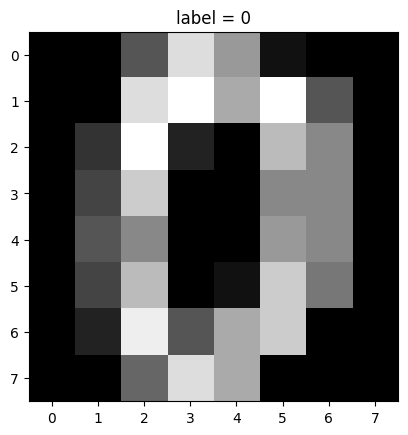

In [3]:
plt.imshow(data.images[0], cmap = "gray")
plt.title(f"label = {data.target[0]}")
plt.show()

## 4. Split Data into Training and Testing Sets

We divide our dataset into 80% training and 20% testing subsets using stratified sampling. This ensures that both sets maintain the same class distribution, providing a fair evaluation of our model's generalization ability on unseen data.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

## 5. Construct ML Pipeline

We create a preprocessing and modeling pipeline that first applies StandardScaler to normalize features to zero mean and unit variance. This is followed by an SVM classifier with RBF kernel, tuned hyperparameters, and probability estimates enabled for confident predictions.

In [5]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel = "rbf", gamma = 0.01, C = 10, probability = True))
])

## 6. Train the Model

We fit the pipeline on the training data. The StandardScaler learns feature statistics from the training set, and the SVM classifier learns decision boundaries to distinguish between different digit classes based on pixel intensities.

In [6]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', SVC(C=10, gamma=0.01, probability=True))])

## 7. Generate Predictions and Compute Accuracy

We apply our trained pipeline to the test set to generate predictions for each digit image. The accuracy metric tells us what percentage of test samples our model correctly classified, serving as an overall performance indicator.

In [7]:
y_pred = pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9833333333333333


## 8. Generate Classification Report

This detailed report shows precision, recall, and F1-score for each digit class. Precision measures correctness for each class, recall measures how many true instances of each class we captured, and F1-score balances both metrics for a comprehensive per-class performance evaluation.

In [8]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.97      0.97      0.97        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.95      0.97      0.96        36
           5       1.00      1.00      1.00        37
           6       0.97      1.00      0.99        36
           7       0.95      1.00      0.97        36
           8       1.00      0.94      0.97        35
           9       1.00      0.94      0.97        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



## 9. Analyze Confusion Matrix

The confusion matrix displays the frequency of true vs. predicted labels in matrix form. It reveals which digit classes the model confuses most frequently, helping us identify specific weaknesses in the classifier's performance on particular digit pairs.

In [9]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[36  0  0  0  0  0  0  0  0  0]
 [ 0 35  0  0  1  0  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 35  0  0  1  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  0 36  0  0  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  1  0  0  1  0  0  0 33  0]
 [ 0  0  0  0  0  0  1  1  0 34]]


## 10. Test Individual Predictions

We visualize a single test sample as an 8x8 grayscale image and display both the true label and the model's prediction. This allows us to inspect individual predictions and understand where the model might make mistakes on specific digit instances.

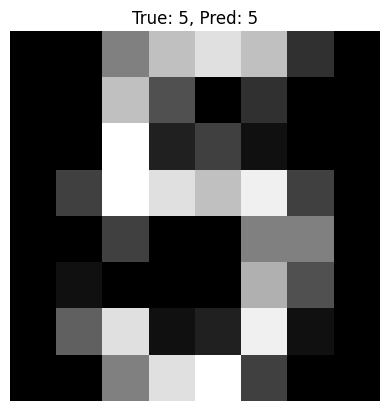

In [10]:
i = 0  # try 0..9 later
plt.imshow(X_test[i].reshape(8, 8), cmap="gray")
plt.title(f"True: {y_test[i]}, Pred: {pipeline.predict([X_test[i]])[0]}")
plt.axis("off")
plt.show()

## 11. Perform Hyperparameter Tuning

We use GridSearchCV to systematically explore different combinations of SVM hyperparameters (C, gamma, and kernel). The 5-fold cross-validation evaluates each combination's performance, and we identify the parameters that yield the highest average validation accuracy.

In [11]:
param_grid = {
    "model__C": [1, 10, 50],
    "model__gamma": [0.01, 0.1, 1],
    "model__kernel" : ["rbf"]
}
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv = 5,
    scoring = "accuracy",
    n_jobs = 1
)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Params: {'model__C': 50, 'model__gamma': 0.01, 'model__kernel': 'rbf'}
Best CV Score: 0.9833018776616338


## 12. Persist the Trained Model

We save the trained pipeline to a pickle file for future use. This allows us to load the model later without retraining, enabling quick predictions on new handwritten digit images and facilitating model deployment to production environments.

In [14]:
import pickle
with open("digit_classifier.pkl", "wb") as file:
    pickle.dump(pipeline, file)